<a href="https://colab.research.google.com/github/Shaurya-XD/diabetic_retinopathy/blob/main/DR_Screening_V4_MULTIDOMAIN_T4_END_TO_END.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Explainable Diabetic Retinopathy Screening — V4 Multi-Domain T4 Pipeline

This notebook is the **new end-to-end classifier pipeline** for the project.

It is designed specifically for:

- **Google Colab Free**
- **NVIDIA T4**
- a practical session budget of roughly **5.5 hours**
- the current `sih` Google Drive layout
- direct EyePACS download from Hugging Face (no EyePACS Drive upload required)

## V4 design

### Classifier training domains

- **APTOS 2019** — existing Drive ZIP
- **EyePACS** — downloaded directly from Hugging Face
- **DDR** — existing `ddr_dr_grading.zip`

### Untouched external test

- **Messidor-2** — `messidor2_external_validation.zip`
- Messidor is **never used for training, calibration, threshold selection, or model selection**

### Segmentation

The existing validated IDRiD MobileNetV2 U-Net is **reused**, not retrained.  
This keeps the T4 runtime focused on improving classification generalization.

## Main improvements over V3

1. Multi-domain training instead of APTOS-only training.
2. EyePACS downloaded directly from Hugging Face.
3. Source-aware, class-controlled sampling.
4. Patient/eye-pair-safe EyePACS validation split.
5. Preprocessed local 300×300 JPEG cache for much faster T4 training.
6. Mixed precision on T4.
7. EfficientNetB0 with two tasks:
   - 5-class DR grade prediction
   - referable-DR binary screening
8. Conservative two-stage transfer learning.
9. Model selection using **QWK + referable AUC**, not accuracy alone.
10. Temperature calibration for grade probabilities.
11. Validation-only fusion of the grade and binary screening heads.
12. Platt calibration of the final screening probability.
13. Validation-only threshold selection targeting high sensitivity.
14. Completely untouched Messidor-2 external evaluation.
15. Existing U-Net + Grad-CAM integrated into the final report generator.
16. Reproducible manifests, metrics, calibration settings, and deployment configuration saved to Drive.

> Screening decision-support research prototype only; not a clinical diagnosis.

---

## Expected Drive layout

The notebook expects a shortcut to the shared `sih` folder under **My Drive**:

```text
My Drive/
└── sih/
    ├── aptos2019-blindness-detection.zip
    ├── ddr_dr_grading.zip
    ├── messidor2_external_validation.zip
    ├── outputs_v3/
    ├── outputs_v3_fixed/
    ├── A. Segmentation.zip
    └── ...
```

If the folder is visible only under **Shared with me**, right-click the `sih` folder in Drive and choose **Organize → Add shortcut**, then place the shortcut in **My Drive**.


In [4]:

# Cell 1 — Install only the extra packages required by V4
# Colab already provides TensorFlow, NumPy, Pandas, OpenCV, SciPy and scikit-learn.

!pip -q install -U huggingface_hub hf_xet reportlab psutil


In [5]:

# Cell 2 — Imports, reproducibility, T4 detection and mixed precision
import os
import sys
import io
import re
import gc
import json
import math
import time
import random
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import Counter

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import psutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision

from scipy.optimize import minimize_scalar
from scipy.special import expit

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score,
    log_loss,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression

from huggingface_hub import hf_hub_download

tf.random.set_seed(SEED)

GPUS = tf.config.list_physical_devices("GPU")
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

GPU_AVAILABLE = bool(GPUS)

if GPU_AVAILABLE:
    mixed_precision.set_global_policy("mixed_float16")

print("=" * 78)
print("ENVIRONMENT")
print("=" * 78)
print("Python      :", sys.version.split()[0])
print("TensorFlow  :", tf.__version__)
print("Keras       :", keras.__version__)
print("GPU         :", GPUS if GPUS else "NOT DETECTED")
print("Mixed policy:", mixed_precision.global_policy())
print("RAM (GB)    :", round(psutil.virtual_memory().total / 1e9, 1))

if not GPU_AVAILABLE:
    print("\nWARNING: GPU is not enabled.")
    print("In Colab choose Runtime → Change runtime type → T4 GPU before training.")


ENVIRONMENT
Python      : 3.13.15
TensorFlow  : 2.20.0
Keras       : 3.13.2
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed policy: <DTypePolicy "mixed_float16">
RAM (GB)    : 13.6


In [6]:

# Cell 3 — Mount Drive and configure paths
from google.colab import drive
drive.mount("/content/drive")

# Shared-with-me folders are not mounted directly.
# The project folder should have a shortcut under My Drive.
DRIVE_CANDIDATES = [
    Path("/content/drive/MyDrive/sih"),
    Path("/content/drive/My Drive/sih"),
]

DRIVE_ROOT = next((p for p in DRIVE_CANDIDATES if p.exists()), None)

if DRIVE_ROOT is None:
    raise FileNotFoundError(
        "Could not find the 'sih' project folder under My Drive.\n"
        "Your screenshot shows Shared with me → sih.\n"
        "In Google Drive, add a shortcut for 'sih' to My Drive, then rerun this cell."
    )

WORK_ROOT = Path("/content/dr_v4_work")
RAW_ROOT = WORK_ROOT / "raw"
CACHE_ROOT = WORK_ROOT / "cache"
OUTPUT_ROOT = DRIVE_ROOT / "outputs_v4_multidomain"

for p in [WORK_ROOT, RAW_ROOT, CACHE_ROOT, OUTPUT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("Drive root :", DRIVE_ROOT)
print("Work root  :", WORK_ROOT)
print("Output root:", OUTPUT_ROOT)

print("\nCurrent top-level Drive files:")
for p in sorted(DRIVE_ROOT.iterdir()):
    print(" -", p.name)


Mounted at /content/drive
Drive root : /content/drive/MyDrive/sih
Work root  : /content/dr_v4_work
Output root: /content/drive/MyDrive/sih/outputs_v4_multidomain

Current top-level Drive files:
 - A. Segmentation.zip
 - B. Disease Grading.zip
 - C. Localization.zip
 - IMAGES.zip.001
 - IMAGES.zip.002
 - IMAGES.zip.003
 - IMAGES.zip.004
 - aptos2019-blindness-detection.zip
 - ddr_dr_grading.zip
 - messidor-2.csv
 - messidor2_external_validation.zip
 - outputs
 - outputs_corrected
 - outputs_v3
 - outputs_v3_fixed
 - outputs_v4_multidomain


In [7]:

# Cell 4 — T4-aware training configuration

CLS_SIZE = (300, 300)
CLS_BATCH = 24 if GPU_AVAILABLE else 6

EYEPACS_TARGET = 6000
DDR_TARGET = 3500

TARGET_CLASS_PROPORTIONS = {
    0: 0.30,
    1: 0.15,
    2: 0.25,
    3: 0.15,
    4: 0.15,
}

HEAD_EPOCHS = 3
FINE_EPOCHS = 6
FINE_TUNE_LAYERS = 45

HEAD_LR = 5e-4
FINE_LR = 1.5e-5
WEIGHT_DECAY = 1e-4

SCREENING_SENSITIVITY_TARGET = 0.90

# Set True only when intentionally discarding compatible V4 checkpoints.
FORCE_RETRAIN = False

CONFIG = {
    "seed": SEED,
    "cls_size": list(CLS_SIZE),
    "batch_size": CLS_BATCH,
    "eyepacs_target": EYEPACS_TARGET,
    "ddr_target": DDR_TARGET,
    "target_class_proportions": TARGET_CLASS_PROPORTIONS,
    "head_epochs": HEAD_EPOCHS,
    "fine_epochs": FINE_EPOCHS,
    "fine_tune_layers": FINE_TUNE_LAYERS,
    "head_lr": HEAD_LR,
    "fine_lr": FINE_LR,
    "screening_sensitivity_target": SCREENING_SENSITIVITY_TARGET,
    "mixed_precision": str(mixed_precision.global_policy()),
}

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "cls_size": [
    300,
    300
  ],
  "batch_size": 24,
  "eyepacs_target": 6000,
  "ddr_target": 3500,
  "target_class_proportions": {
    "0": 0.3,
    "1": 0.15,
    "2": 0.25,
    "3": 0.15,
    "4": 0.15
  },
  "head_epochs": 3,
  "fine_epochs": 6,
  "fine_tune_layers": 45,
  "head_lr": 0.0005,
  "fine_lr": 1.5e-05,
  "screening_sensitivity_target": 0.9,
  "mixed_precision": "<DTypePolicy \"mixed_float16\">"
}


In [8]:

# Cell 5 — General archive, schema, sampling and image-cache helpers

IMG_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

def copy_with_progress(src, dst):
    src = Path(src)
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists() and dst.stat().st_size == src.stat().st_size:
        print("Already copied:", dst)
        return dst

    total = src.stat().st_size
    with open(src, "rb") as fi, open(dst, "wb") as fo, tqdm(
        total=total,
        unit="B",
        unit_scale=True,
        desc=f"Copy {src.name}",
    ) as bar:
        while True:
            chunk = fi.read(16 * 1024 * 1024)
            if not chunk:
                break
            fo.write(chunk)
            bar.update(len(chunk))

    return dst

def robust_read_csv_bytes(data):
    attempts = []

    for kwargs in [
        {},
        {"sep": None, "engine": "python"},
        {"sep": ";"},
        {"sep": "\t"},
    ]:
        try:
            df = pd.read_csv(io.BytesIO(data), **kwargs)
            if df.shape[1] >= 2:
                attempts.append(df)
        except Exception:
            pass

    if not attempts:
        raise ValueError("Could not parse CSV.")

    attempts.sort(key=lambda x: (x.shape[1], x.notna().sum().sum()), reverse=True)
    df = attempts[0].copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

def read_csv_from_zip(zip_path, preferred_names=None):
    preferred_names = preferred_names or []

    with zipfile.ZipFile(zip_path) as z:
        csv_members = [i for i in z.infolist() if i.filename.lower().endswith(".csv")]

        if not csv_members:
            raise FileNotFoundError(f"No CSV found inside {zip_path}")

        chosen = None

        for wanted in preferred_names:
            for info in csv_members:
                if Path(info.filename).name.lower() == wanted.lower():
                    chosen = info
                    break
            if chosen:
                break

        if chosen is None:
            ranked = sorted(
                csv_members,
                key=lambda i: (
                    -int(any(k in i.filename.lower() for k in ["grading", "train", "label", "messidor_data"])),
                    len(i.filename),
                ),
            )
            chosen = ranked[0]

        data = z.read(chosen)

    return robust_read_csv_bytes(data), chosen.filename

def find_col(df, candidates):
    low = {str(c).strip().lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in low:
            return low[c.lower()]

    for col in df.columns:
        cl = str(col).strip().lower()
        if any(c.lower() in cl for c in candidates):
            return col

    return None

def normalize_stem(value):
    if pd.isna(value):
        return None
    return Path(str(value).strip()).stem.lower()

def infer_id_and_grade_columns(df):
    id_col = find_col(
        df,
        [
            "id_code",
            "image",
            "image_id",
            "image name",
            "image_name",
            "filename",
            "file",
            "name",
        ],
    )

    grade_col = find_col(
        df,
        [
            "diagnosis",
            "adjudicated_dr_grade",
            "dr_grade",
            "level",
            "grade",
            "severity",
            "label",
        ],
    )

    if grade_col is None:
        candidates = []

        for col in df.columns:
            if col == id_col:
                continue

            cl = str(col).lower()
            if any(bad in cl for bad in ["dme", "gradable", "quality", "left", "right"]):
                continue

            numeric = pd.to_numeric(df[col], errors="coerce")
            valid = numeric.dropna()

            if len(valid) < max(20, int(0.25 * len(df))):
                continue

            rounded = np.round(valid).astype(int)
            unique = set(rounded.tolist())

            if unique.issubset({0, 1, 2, 3, 4}) and len(unique) >= 2:
                candidates.append(col)

        if candidates:
            grade_col = candidates[0]

    return id_col, grade_col

def zip_image_member_map(zip_path):
    mapping = {}
    info_by_name = {}

    with zipfile.ZipFile(zip_path) as z:
        for info in z.infolist():
            suffix = Path(info.filename).suffix.lower()

            if suffix not in IMG_EXTS:
                continue

            stem = Path(info.filename).stem.lower()
            mapping.setdefault(stem, info.filename)
            info_by_name[info.filename] = info.header_offset

    return mapping, info_by_name

def allocate_class_quotas(df, target_n, proportions):
    counts = df["label"].value_counts().to_dict()
    target_n = min(int(target_n), len(df))

    quotas = {
        c: min(
            int(round(target_n * proportions.get(c, 0.0))),
            int(counts.get(c, 0)),
        )
        for c in range(5)
    }

    remaining = target_n - sum(quotas.values())

    while remaining > 0:
        available = [
            c for c in range(5)
            if quotas[c] < int(counts.get(c, 0))
        ]

        if not available:
            break

        available.sort(
            key=lambda c: (
                quotas[c] / max(1, int(counts.get(c, 0))),
                -c,
            )
        )

        progressed = False

        for c in available:
            if remaining <= 0:
                break

            if quotas[c] < int(counts.get(c, 0)):
                quotas[c] += 1
                remaining -= 1
                progressed = True

        if not progressed:
            break

    return quotas

def stratified_cap(df, target_n, proportions, seed=SEED):
    quotas = allocate_class_quotas(df, target_n, proportions)
    parts = []

    for c in range(5):
        sub = df[df["label"] == c]
        n = min(quotas[c], len(sub))

        if n:
            parts.append(sub.sample(n=n, random_state=seed + c))

    out = pd.concat(parts, ignore_index=True)
    out = out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    print("Sampling quotas:", quotas)
    print("Sampled distribution:")
    print(out["label"].value_counts().sort_index())
    print("Total:", len(out))

    return out

def black_border_crop_bgr(img, threshold=10):
    if img is None or img.size == 0:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    coords = np.argwhere(gray > threshold)

    if len(coords) == 0:
        return img

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return img[int(y0):int(y1), int(x0):int(x1)]

def preprocess_bgr_to_classifier(img):
    crop = black_border_crop_bgr(img)

    if crop is None or crop.size == 0:
        return None

    resized = cv2.resize(
        crop,
        (CLS_SIZE[1], CLS_SIZE[0]),
        interpolation=cv2.INTER_AREA,
    )

    return resized

def cache_manifest_from_zip(
    zip_path,
    df,
    id_col,
    out_dir,
    source_name,
    require_match_rate=0.90,
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    member_map, offsets = zip_image_member_map(zip_path)

    work = df.copy().reset_index(drop=True)
    work["__orig_order"] = np.arange(len(work))
    work["__stem"] = work[id_col].map(normalize_stem)
    work["__member"] = work["__stem"].map(member_map)

    match_rate = float(work["__member"].notna().mean())
    print(f"{source_name} ZIP filename match rate: {match_rate:.4f}")

    if match_rate < require_match_rate:
        raise RuntimeError(
            f"{source_name}: only {match_rate:.1%} of selected labels matched ZIP images."
        )

    work = work.dropna(subset=["__member"]).copy()
    work["__offset"] = work["__member"].map(offsets)
    work = work.sort_values("__offset").reset_index(drop=True)

    cached_rows = []

    with zipfile.ZipFile(zip_path) as z:
        for _, row in tqdm(
            work.iterrows(),
            total=len(work),
            desc=f"Cache {source_name}",
        ):
            member = row["__member"]

            try:
                data = z.read(member)
                arr = np.frombuffer(data, dtype=np.uint8)
                img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                img = preprocess_bgr_to_classifier(img)

                if img is None:
                    continue

                dst = out_dir / f"{source_name}_{row['__stem']}.jpg"

                ok = cv2.imwrite(
                    str(dst),
                    img,
                    [int(cv2.IMWRITE_JPEG_QUALITY), 92],
                )

                if not ok:
                    continue

                rec = row.to_dict()
                rec["filepath"] = str(dst)
                rec["source"] = source_name
                cached_rows.append(rec)

            except Exception as e:
                print("Skipping unreadable member:", member, type(e).__name__)

    cached = pd.DataFrame(cached_rows)

    if len(cached) < 0.95 * len(work):
        raise RuntimeError(
            f"{source_name}: too many selected images failed preprocessing "
            f"({len(cached)}/{len(work)} cached)."
        )

    # Restore the original CSV/sample ordering after archive-ordered reading.
    cached = cached.sort_values("__orig_order").reset_index(drop=True)

    return cached

def derive_patient_group(value):
    stem = normalize_stem(value) or ""
    stem = re.sub(r"([_-])(left|right)$", "", stem, flags=re.IGNORECASE)
    stem = re.sub(r"([_-])([lr])$", "", stem, flags=re.IGNORECASE)
    return stem

print("Helper functions ready.")


Helper functions ready.


In [9]:

# Cell 6 — Resolve Drive archives and directly download EyePACS from Hugging Face

APTOS_DRIVE = DRIVE_ROOT / "aptos2019-blindness-detection.zip"
DDR_DRIVE = DRIVE_ROOT / "ddr_dr_grading.zip"
MESSIDOR_DRIVE = DRIVE_ROOT / "messidor2_external_validation.zip"

for required in [APTOS_DRIVE, DDR_DRIVE, MESSIDOR_DRIVE]:
    if not required.exists():
        raise FileNotFoundError(f"Required file not found: {required}")

# Local copies avoid thousands of random reads through Google Drive.
APTOS_ZIP = copy_with_progress(APTOS_DRIVE, RAW_ROOT / APTOS_DRIVE.name)
DDR_ZIP = copy_with_progress(DDR_DRIVE, RAW_ROOT / DDR_DRIVE.name)
MESSIDOR_ZIP = copy_with_progress(MESSIDOR_DRIVE, RAW_ROOT / MESSIDOR_DRIVE.name)

HF_REPO = "ctmedtech/EYEPACS"
HF_DIR = RAW_ROOT / "eyepacs_hf"
HF_DIR.mkdir(parents=True, exist_ok=True)

print("\nDownloading EyePACS labels directly from Hugging Face...")
EYEPACS_LABELS = Path(
    hf_hub_download(
        repo_id=HF_REPO,
        filename="trainLabels.csv",
        repo_type="dataset",
        local_dir=str(HF_DIR),
    )
)

print("\nDownloading EyePACS image archive directly from Hugging Face...")
print("This is the large ~6.5 GB direct download.")
EYEPACS_ZIP = Path(
    hf_hub_download(
        repo_id=HF_REPO,
        filename="EYEPACS.zip",
        repo_type="dataset",
        local_dir=str(HF_DIR),
    )
)

print("\nResolved:")
print("APTOS     :", APTOS_ZIP)
print("DDR       :", DDR_ZIP)
print("Messidor  :", MESSIDOR_ZIP)
print("EyePACS   :", EYEPACS_ZIP)
print("Eye labels:", EYEPACS_LABELS)


Copy aptos2019-blindness-detection.zip:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Copy ddr_dr_grading.zip:   0%|          | 0.00/3.20G [00:00<?, ?B/s]

Copy messidor2_external_validation.zip:   0%|          | 0.00/399M [00:00<?, ?B/s]

trainLabels.csv:   0%|          | 0.00/500k [00:00<?, ?B/s]


This is the large ~6.5 GB direct download.


EYEPACS.zip: reconstructing file:   0%|          |  0.00B / 6.48GB            

EYEPACS.zip: downloading bytes:           |  0.00B            


Resolved:
APTOS     : /content/dr_v4_work/raw/aptos2019-blindness-detection.zip
DDR       : /content/dr_v4_work/raw/ddr_dr_grading.zip
Messidor  : /content/dr_v4_work/raw/messidor2_external_validation.zip
EyePACS   : /content/dr_v4_work/raw/eyepacs_hf/EYEPACS.zip
Eye labels: /content/dr_v4_work/raw/eyepacs_hf/trainLabels.csv


In [10]:

# Cell 7 — Build and cache the complete APTOS labeled set

aptos_raw, aptos_csv_member = read_csv_from_zip(
    APTOS_ZIP,
    preferred_names=["train.csv"],
)

aptos_id_col, aptos_grade_col = infer_id_and_grade_columns(aptos_raw)

print("APTOS CSV member:", aptos_csv_member)
print("APTOS columns   :", list(aptos_raw.columns))
print("ID column       :", aptos_id_col)
print("Grade column    :", aptos_grade_col)

if aptos_id_col is None or aptos_grade_col is None:
    raise RuntimeError("Could not identify APTOS image/grade columns.")

aptos = aptos_raw.copy()
aptos["label"] = pd.to_numeric(aptos[aptos_grade_col], errors="coerce")
aptos = aptos.dropna(subset=["label"]).copy()
aptos["label"] = aptos["label"].astype(int)
aptos = aptos[aptos["label"].between(0, 4)].reset_index(drop=True)

if set(aptos["label"].unique()) != {0, 1, 2, 3, 4}:
    raise RuntimeError("APTOS does not contain the expected five classes.")

APTOS_CACHE = CACHE_ROOT / "aptos"

aptos_cached = cache_manifest_from_zip(
    APTOS_ZIP,
    aptos,
    aptos_id_col,
    APTOS_CACHE,
    source_name="aptos",
    require_match_rate=0.95,
)

APTOS_CACHE_COMPLETE = len(aptos_cached) == len(aptos)

print("\nAPTOS usable cached images:", len(aptos_cached))
print("APTOS cache complete      :", APTOS_CACHE_COMPLETE)
print(aptos_cached["label"].value_counts().sort_index())


APTOS CSV member: train.csv
APTOS columns   : ['id_code', 'diagnosis']
ID column       : id_code
Grade column    : diagnosis
aptos ZIP filename match rate: 1.0000


Cache aptos:   0%|          | 0/3662 [00:00<?, ?it/s]


APTOS usable cached images: 3662
APTOS cache complete      : True
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [11]:

# Cell 8 — EyePACS direct Hugging Face labels, controlled sampling and local cache

eyepacs_raw = pd.read_csv(EYEPACS_LABELS)
eyepacs_raw.columns = [str(c).strip() for c in eyepacs_raw.columns]

eye_id_col, eye_grade_col = infer_id_and_grade_columns(eyepacs_raw)

print("EyePACS columns:", list(eyepacs_raw.columns))
print("ID column      :", eye_id_col)
print("Grade column   :", eye_grade_col)

if eye_id_col is None or eye_grade_col is None:
    raise RuntimeError("Could not identify EyePACS image/grade columns.")

eyepacs = eyepacs_raw.copy()
eyepacs["label"] = pd.to_numeric(eyepacs[eye_grade_col], errors="coerce")
eyepacs = eyepacs.dropna(subset=["label"]).copy()
eyepacs["label"] = eyepacs["label"].astype(int)
eyepacs = eyepacs[eyepacs["label"].between(0, 4)].reset_index(drop=True)

print("\nFull EyePACS labeled distribution:")
print(eyepacs["label"].value_counts().sort_index())

eyepacs_sample = stratified_cap(
    eyepacs,
    target_n=EYEPACS_TARGET,
    proportions=TARGET_CLASS_PROPORTIONS,
)

EYEPACS_CACHE = CACHE_ROOT / "eyepacs"

eyepacs_cached = cache_manifest_from_zip(
    EYEPACS_ZIP,
    eyepacs_sample,
    eye_id_col,
    EYEPACS_CACHE,
    source_name="eyepacs",
    require_match_rate=0.90,
)

eyepacs_cached["group_id"] = eyepacs_cached[eye_id_col].map(derive_patient_group)

print("\nEyePACS cached:", len(eyepacs_cached))
print(eyepacs_cached["label"].value_counts().sort_index())
print("Patient/examination groups:", eyepacs_cached["group_id"].nunique())


EyePACS columns: ['image', 'level']
ID column      : image
Grade column   : level

Full EyePACS labeled distribution:
label
0    25802
1     2438
2     5288
3      872
4      708
Name: count, dtype: int64
Sampling quotas: {0: 1874, 1: 973, 2: 1573, 3: 872, 4: 708}
Sampled distribution:
label
0    1874
1     973
2    1573
3     872
4     708
Name: count, dtype: int64
Total: 6000
eyepacs ZIP filename match rate: 1.0000


Cache eyepacs:   0%|          | 0/6000 [00:00<?, ?it/s]


EyePACS cached: 6000
label
0    1874
1     973
2    1573
3     872
4     708
Name: count, dtype: int64
Patient/examination groups: 4842


In [12]:

# Cell 9 — DDR grading labels, controlled sampling and local cache

ddr_raw, ddr_csv_member = read_csv_from_zip(
    DDR_ZIP,
    preferred_names=["DR_grading.csv", "dr_grading.csv"],
)

ddr_id_col, ddr_grade_col = infer_id_and_grade_columns(ddr_raw)

print("DDR CSV member:", ddr_csv_member)
print("DDR columns   :", list(ddr_raw.columns))
print("ID column     :", ddr_id_col)
print("Grade column  :", ddr_grade_col)

if ddr_id_col is None or ddr_grade_col is None:
    raise RuntimeError("Could not identify DDR image/grade columns.")

ddr = ddr_raw.copy()
ddr["label"] = pd.to_numeric(ddr[ddr_grade_col], errors="coerce")
ddr = ddr.dropna(subset=["label"]).copy()
ddr["label"] = ddr["label"].astype(int)
ddr = ddr[ddr["label"].between(0, 4)].reset_index(drop=True)

print("\nFull usable DDR grading distribution:")
print(ddr["label"].value_counts().sort_index())

ddr_sample = stratified_cap(
    ddr,
    target_n=DDR_TARGET,
    proportions=TARGET_CLASS_PROPORTIONS,
)

DDR_CACHE = CACHE_ROOT / "ddr"

ddr_cached = cache_manifest_from_zip(
    DDR_ZIP,
    ddr_sample,
    ddr_id_col,
    DDR_CACHE,
    source_name="ddr",
    require_match_rate=0.90,
)

ddr_cached["group_id"] = ddr_cached[ddr_id_col].map(derive_patient_group)

print("\nDDR cached:", len(ddr_cached))
print(ddr_cached["label"].value_counts().sort_index())
print("Derived groups:", ddr_cached["group_id"].nunique())


DDR CSV member: DR_grading.csv
DDR columns   : ['id_code', 'diagnosis']
ID column     : id_code
Grade column  : diagnosis

Full usable DDR grading distribution:
label
0    6266
1     630
2    4477
3     236
4     913
Name: count, dtype: int64
Sampling quotas: {0: 1123, 1: 597, 2: 947, 3: 236, 4: 597}
Sampled distribution:
label
0    1123
1     597
2     947
3     236
4     597
Name: count, dtype: int64
Total: 3500
ddr ZIP filename match rate: 1.0000


Cache ddr:   0%|          | 0/3500 [00:00<?, ?it/s]


DDR cached: 3500
label
0    1123
1     597
2     947
3     236
4     597
Name: count, dtype: int64
Derived groups: 3500


In [13]:

# Cell 10 — Leakage-conscious train / validation / held-out APTOS test splits

# Preserve the same APTOS split methodology and ordering as V3.
aptos_train, aptos_temp = train_test_split(
    aptos_cached,
    test_size=0.30,
    stratify=aptos_cached["label"],
    random_state=SEED,
)

aptos_val, aptos_test = train_test_split(
    aptos_temp,
    test_size=0.50,
    stratify=aptos_temp["label"],
    random_state=SEED,
)

def group_train_val_split(df, val_size=0.10, seed=SEED):
    work = df.copy()

    if "group_id" not in work.columns:
        work["group_id"] = work.index.astype(str)

    group_table = (
        work.groupby("group_id", as_index=False)["label"]
        .max()
        .rename(columns={"label": "group_label"})
    )

    try:
        train_groups, val_groups = train_test_split(
            group_table,
            test_size=val_size,
            stratify=group_table["group_label"],
            random_state=seed,
        )
    except ValueError:
        train_groups, val_groups = train_test_split(
            group_table,
            test_size=val_size,
            random_state=seed,
        )

    train_ids = set(train_groups["group_id"])
    val_ids = set(val_groups["group_id"])

    tr = work[work["group_id"].isin(train_ids)].copy()
    va = work[work["group_id"].isin(val_ids)].copy()

    if set(tr["group_id"]) & set(va["group_id"]):
        raise RuntimeError("Patient/group leakage detected.")

    return tr.reset_index(drop=True), va.reset_index(drop=True)

eye_train, eye_val = group_train_val_split(eyepacs_cached, val_size=0.10)
ddr_train, ddr_val = group_train_val_split(ddr_cached, val_size=0.10)

train_df = pd.concat(
    [aptos_train, eye_train, ddr_train],
    ignore_index=True,
).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

val_df = pd.concat(
    [aptos_val, eye_val, ddr_val],
    ignore_index=True,
).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

test_df = aptos_test.reset_index(drop=True)

print("=" * 78)
print("FINAL V4 SPLITS")
print("=" * 78)

for name, df in [
    ("TRAIN — multi-domain", train_df),
    ("VALIDATION — multi-domain", val_df),
    ("FINAL INTERNAL TEST — APTOS only", test_df),
]:
    print(f"\n{name}: {len(df)}")
    print("By source:")
    print(df["source"].value_counts())
    print("By grade:")
    print(df["label"].value_counts().sort_index())

MANIFEST_DIR = OUTPUT_ROOT / "manifests"
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(MANIFEST_DIR / "train_manifest.csv", index=False)
val_df.to_csv(MANIFEST_DIR / "validation_manifest.csv", index=False)
test_df.to_csv(MANIFEST_DIR / "aptos_final_test_manifest.csv", index=False)

print("\nSaved exact split manifests to:", MANIFEST_DIR)


FINAL V4 SPLITS

TRAIN — multi-domain: 11113
By source:
source
eyepacs    5400
ddr        3150
aptos      2563
Name: count, dtype: int64
By grade:
label
0    3964
1    1671
2    2960
3    1142
4    1376
Name: count, dtype: int64

VALIDATION — multi-domain: 1499
By source:
source
eyepacs    600
aptos      549
ddr        350
Name: count, dtype: int64
By grade:
label
0    567
1    213
2    409
3    130
4    180
Name: count, dtype: int64

FINAL INTERNAL TEST — APTOS only: 550
By source:
source
aptos    550
Name: count, dtype: int64
By grade:
label
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64

Saved exact split manifests to: /content/drive/MyDrive/sih/outputs_v4_multidomain/manifests


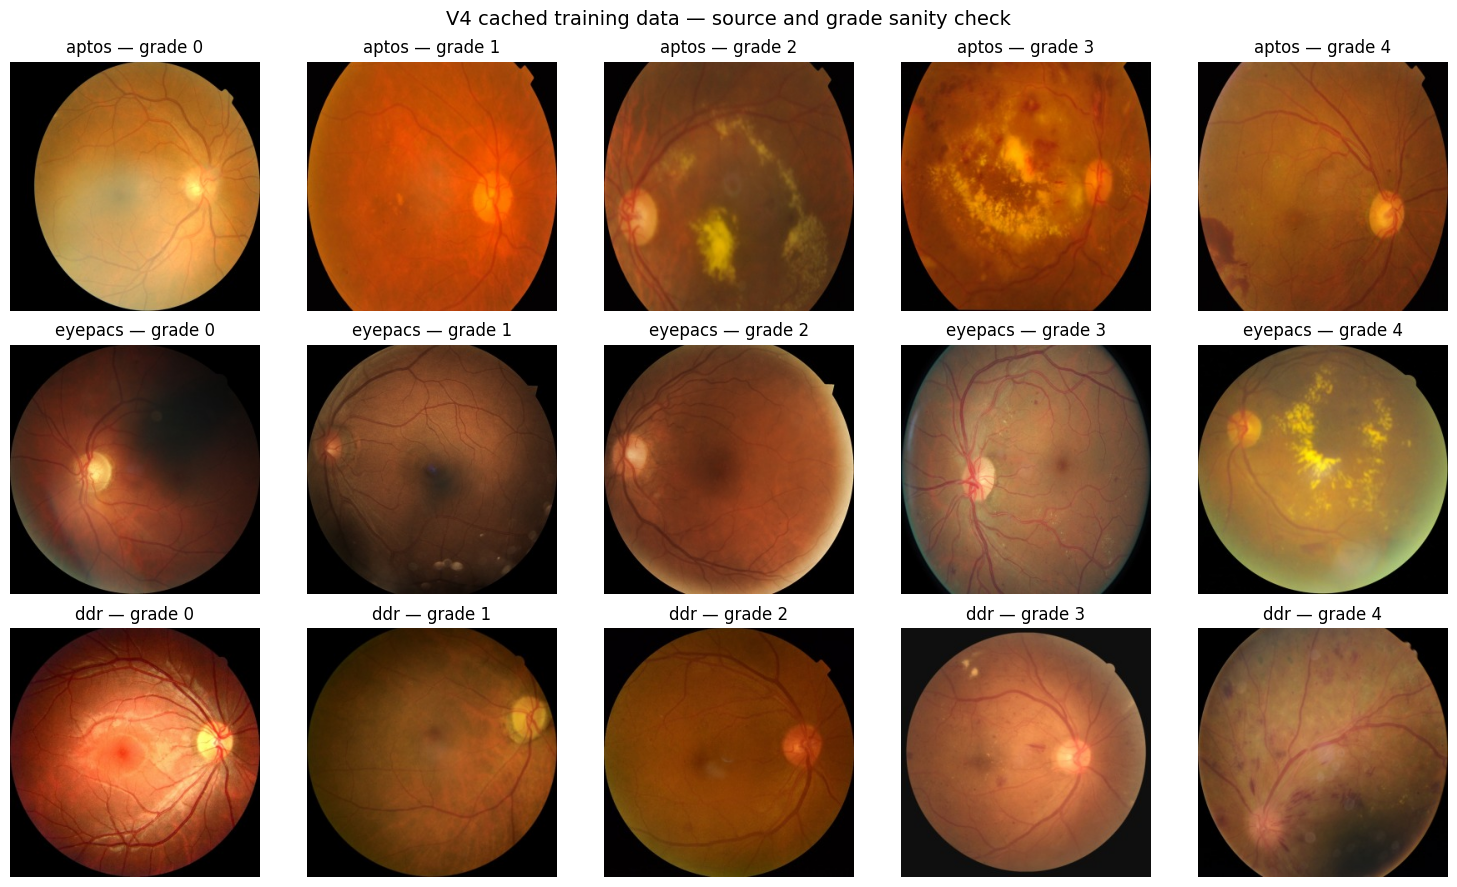

Verify that all panels are retinal fundus photographs and that the three domains show realistic acquisition differences.


In [14]:

# Cell 11 — Visual multi-domain sanity check

sources = ["aptos", "eyepacs", "ddr"]

fig, axes = plt.subplots(len(sources), 5, figsize=(15, 9))

for r, source in enumerate(sources):
    source_df = train_df[train_df["source"] == source]

    for grade in range(5):
        ax = axes[r, grade]
        candidates = source_df[source_df["label"] == grade]

        if len(candidates) == 0:
            ax.axis("off")
            continue

        row = candidates.sample(1, random_state=SEED + r * 10 + grade).iloc[0]

        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        ax.set_title(f"{source} — grade {grade}")
        ax.axis("off")

plt.suptitle("V4 cached training data — source and grade sanity check", fontsize=14)
plt.tight_layout()
plt.show()

print(
    "Verify that all panels are retinal fundus photographs and that the three "
    "domains show realistic acquisition differences."
)


In [15]:

# Cell 12 — Fast local tf.data pipeline, realistic augmentation and moderate sample weighting

AUTOTUNE = tf.data.AUTOTUNE

classifier_augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.04, fill_mode="reflect"),
        layers.RandomZoom(
            height_factor=(-0.06, 0.08),
            width_factor=(-0.06, 0.08),
            fill_mode="reflect",
        ),
        layers.RandomContrast(0.15),
        layers.RandomBrightness(
            factor=0.08,
            value_range=(0.0, 255.0),
        ),
    ],
    name="v4_domain_augmentation",
)

train_counts = train_df["label"].value_counts().reindex(range(5), fill_value=1).to_numpy()
grade_weights = np.sqrt(train_counts.sum() / (5.0 * train_counts))
grade_weights = grade_weights / grade_weights.mean()
grade_weights = np.clip(grade_weights, 0.65, 2.25).astype(np.float32)

ref_labels_train = (train_df["label"].to_numpy() >= 2).astype(int)
ref_counts = np.bincount(ref_labels_train, minlength=2)
ref_weights = np.sqrt(ref_counts.sum() / (2.0 * np.maximum(ref_counts, 1)))
ref_weights = ref_weights / ref_weights.mean()
ref_weights = np.clip(ref_weights, 0.70, 1.80).astype(np.float32)

print("Grade weights:", grade_weights)
print("Referable weights:", ref_weights)

GRADE_WEIGHT_TABLE = tf.constant(grade_weights, dtype=tf.float32)
REF_WEIGHT_TABLE = tf.constant(ref_weights, dtype=tf.float32)

def decode_cached_jpeg(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img.set_shape([CLS_SIZE[0], CLS_SIZE[1], 3])
    return tf.cast(img, tf.float32)

def make_training_ds(df, training=True, batch_size=CLS_BATCH):
    paths = df["filepath"].astype(str).to_numpy()
    labels = df["label"].astype(np.int32).to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    def load(path, label):
        img = decode_cached_jpeg(path)

        if training:
            img = classifier_augment(img, training=True)
            img = tf.clip_by_value(img, 0.0, 255.0)

        ref = tf.cast(label >= 2, tf.float32)

        targets = {
            "grade": label,
            "referable": tf.expand_dims(ref, axis=-1),
        }

        weights = {
            "grade": tf.gather(GRADE_WEIGHT_TABLE, label),
            "referable": tf.gather(REF_WEIGHT_TABLE, tf.cast(ref, tf.int32)),
        }

        return img, targets, weights

    ds = ds.map(load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)

    return ds

def make_predict_ds(df, batch_size=CLS_BATCH):
    paths = df["filepath"].astype(str).to_numpy()

    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(decode_cached_jpeg, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = make_training_ds(train_df, training=True)
val_ds = make_training_ds(val_df, training=False)

x_batch, y_batch, w_batch = next(iter(val_ds))

print("Batch image shape:", x_batch.shape)
print("Batch image min/max:", float(tf.reduce_min(x_batch)), float(tf.reduce_max(x_batch)))
print("Grade target shape:", y_batch["grade"].shape)
print("Referable target shape:", y_batch["referable"].shape)

if float(tf.reduce_max(x_batch)) <= 1.5:
    raise RuntimeError(
        "V4 classifier images appear normalized to 0–1. "
        "Keras EfficientNetB0 expects the 0–255 float range in this pipeline."
    )


Grade weights: [0.6889117 1.0610653 0.7972316 1.2835042 1.1692871]
Referable weights: [0.99293584 1.0070641 ]
Batch image shape: (24, 300, 300, 3)
Batch image min/max: 0.0 255.0
Grade target shape: (24,)
Referable target shape: (24, 1)


In [16]:

# Cell 13 — Build V4 EfficientNetB0 multi-task classifier and initialize from V3 when safe

def build_v4_classifier():
    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*CLS_SIZE, 3),
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(*CLS_SIZE, 3), name="fundus")
    x = backbone(inputs, training=False)
    features = layers.GlobalAveragePooling2D(name="gap")(x)

    grade_x = layers.Dropout(0.32, name="grade_dropout")(features)
    grade_logits = layers.Dense(
        5,
        name="grade_logits",
        dtype="float32",
    )(grade_x)
    grade = layers.Activation(
        "softmax",
        name="grade",
        dtype="float32",
    )(grade_logits)

    ref_x = layers.Dropout(0.25, name="referable_dropout")(features)
    referable_logit = layers.Dense(
        1,
        name="referable_logit",
        dtype="float32",
    )(ref_x)
    referable = layers.Activation(
        "sigmoid",
        name="referable",
        dtype="float32",
    )(referable_logit)

    model = keras.Model(
        inputs=inputs,
        outputs={
            "grade": grade,
            "referable": referable,
        },
        name="DR_MultiDomain_EfficientNetB0_V4",
    )

    return model, backbone

model, cls_backbone = build_v4_classifier()

def find_existing_v3_classifier():
    roots = [
        DRIVE_ROOT / "outputs_v3_fixed",
        DRIVE_ROOT / "outputs_v3",
        DRIVE_ROOT / "outputs_corrected",
        DRIVE_ROOT / "outputs",
    ]

    preferred_names = [
        "aptos_efficientnetb0_final.keras",
        "classifier_finetuned_best.keras",
        "classifier_head_best.keras",
    ]

    for root in roots:
        if not root.exists():
            continue

        for name in preferred_names:
            matches = list(root.rglob(name))

            if matches:
                return matches[0]

    return None

V3_CLASSIFIER = find_existing_v3_classifier()

# Transfer only when the original APTOS labeled set cached completely,
# preserving the V3 CSV ordering and therefore its held-out split methodology.
if V3_CLASSIFIER is not None and APTOS_CACHE_COMPLETE:
    try:
        old_model = keras.models.load_model(V3_CLASSIFIER, compile=False)

        old_backbone = old_model.get_layer("efficientnetb0")
        cls_backbone.set_weights(old_backbone.get_weights())

        old_grade = old_model.get_layer("grade")

        if old_grade.get_weights():
            model.get_layer("grade_logits").set_weights(old_grade.get_weights())

        print("Initialized V4 backbone and grade head from:", V3_CLASSIFIER)

        del old_model
        gc.collect()

    except Exception as e:
        print("WARNING: V3 transfer initialization failed:", type(e).__name__, e)
        print("Continuing from ImageNet initialization.")
else:
    print("Using ImageNet initialization; V3 transfer was unavailable or not leakage-safe.")

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Initialized V4 backbone and grade head from: /content/drive/MyDrive/sih/outputs_v3/aptos_efficientnetb0_final.keras


Model: "DR_MultiDomain_EfficientNetB0_V4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fundus (InputLayer) │ (None, 300, 300,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 10, 10,    │  4,049,571 │ fundus[0][0]      │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grade_dropout       │ (None, 1280)      │          0 │ gap[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ referable_dropout   │ (None, 1280)      │          0 │ gap[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grade_logits        │ (None, 5)         │      6,405 │ grade_dropout[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ referable_logit     │ (None, 1)         │      1,281 │ referable_dropou… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grade (Activation)  │ (None, 5)         │          0 │ grade_logits[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ referable           │ (None, 1)         │          0 │ referable_logit[… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:

# Cell 14 — Compile helper and Stage 1: train the new multi-task heads

def make_optimizer(lr):
    try:
        return keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=WEIGHT_DECAY,
            clipnorm=1.0,
        )
    except Exception:
        return keras.optimizers.Adam(
            learning_rate=lr,
            clipnorm=1.0,
        )

def compile_v4(model, lr):
    model.compile(
        optimizer=make_optimizer(lr),
        loss={
            "grade": keras.losses.SparseCategoricalCrossentropy(),
            "referable": keras.losses.BinaryCrossentropy(),
        },
        loss_weights={
            "grade": 1.0,
            "referable": 0.65,
        },
        metrics={
            "grade": [
                keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            ],
            "referable": [
                keras.metrics.AUC(name="auc"),
                keras.metrics.Recall(name="recall"),
            ],
        },
    )

HEAD_CKPT = OUTPUT_ROOT / "v4_head_best.keras"

compile_v4(model, HEAD_LR)

if HEAD_CKPT.exists() and not FORCE_RETRAIN:
    print("Existing Stage-1 checkpoint found; loading:", HEAD_CKPT)
    model = keras.models.load_model(HEAD_CKPT, compile=False)
    cls_backbone = model.get_layer("efficientnetb0")
    hist_head = None
else:
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(HEAD_CKPT),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.35,
            patience=1,
            min_lr=2e-6,
            verbose=1,
        ),
    ]

    print("Training V4 Stage 1 — frozen EfficientNet backbone...")
    hist_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=HEAD_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    model = keras.models.load_model(HEAD_CKPT, compile=False)
    cls_backbone = model.get_layer("efficientnetb0")

print("Stage 1 ready:", HEAD_CKPT)


Training V4 Stage 1 — frozen EfficientNet backbone...
Epoch 1/3
464/464 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - grade_accuracy: 0.4619 - grade_loss: 1.2873 - loss: 1.6844 - referable_auc: 0.7171 - referable_loss: 0.6110 - referable_recall: 0.6165
Epoch 1: val_loss improved from None to 1.28940, saving model to /content/drive/MyDrive/sih/outputs_v4_multidomain/v4_head_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/sih/outputs_v4_multidomain/v4_head_best.keras
464/464 ━━━━━━━━━━━━━━━━━━━━ 505s 942ms/step - grade_accuracy: 0.4742 - grade_loss: 1.1961 - loss: 1.5599 - referable_auc: 0.7899 - referable_loss: 0.5590 - referable_recall: 0.6736 - val_grade_accuracy: 0.5564 - val_grade_loss: 0.9985 - val_loss: 1.2894 - val_referable_auc: 0.8904 - val_referable_loss: 0.4510 - val_referable_recall: 0.7636 - learning_rate: 5.0000e-04
Epoch 2/3
463/464 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - grade_accuracy: 0.5112 - grade_loss: 1.1014 - loss: 1.4276 - referable_auc: 0.8350 - referab

In [18]:

# Cell 15 — Stage 2: conservative partial EfficientNet fine-tuning

FINE_CKPT = OUTPUT_ROOT / "v4_finetuned_best.keras"

if FINE_CKPT.exists() and not FORCE_RETRAIN:
    print("Existing Stage-2 checkpoint found; loading:", FINE_CKPT)
    fine_model = keras.models.load_model(FINE_CKPT, compile=False)
    hist_fine = None
else:
    cls_backbone = model.get_layer("efficientnetb0")
    cls_backbone.trainable = True

    for layer in cls_backbone.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False

    for layer in cls_backbone.layers[-FINE_TUNE_LAYERS:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    print(
        "Trainable EfficientNet layers:",
        sum(int(layer.trainable) for layer in cls_backbone.layers),
        "/",
        len(cls_backbone.layers),
    )

    compile_v4(model, FINE_LR)

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(FINE_CKPT),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.35,
            patience=1,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    print("Training V4 Stage 2 — final EfficientNet layers only...")
    hist_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    fine_model = keras.models.load_model(FINE_CKPT, compile=False)

print("Stage 2 ready:", FINE_CKPT)


Trainable EfficientNet layers: 35 / 238
Training V4 Stage 2 — final EfficientNet layers only...
Epoch 1/6
464/464 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - grade_accuracy: 0.5318 - grade_loss: 1.0500 - loss: 1.3543 - referable_auc: 0.8577 - referable_loss: 0.4681 - referable_recall: 0.7376
Epoch 1: val_loss improved from None to 1.17847, saving model to /content/drive/MyDrive/sih/outputs_v4_multidomain/v4_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/sih/outputs_v4_multidomain/v4_finetuned_best.keras
464/464 ━━━━━━━━━━━━━━━━━━━━ 534s 1s/step - grade_accuracy: 0.5413 - grade_loss: 1.0342 - loss: 1.3314 - referable_auc: 0.8646 - referable_loss: 0.4576 - referable_recall: 0.7446 - val_grade_accuracy: 0.5804 - val_grade_loss: 0.9316 - val_loss: 1.1785 - val_referable_auc: 0.9162 - val_referable_loss: 0.3823 - val_referable_recall: 0.8220 - learning_rate: 1.5000e-05
Epoch 2/6
463/464 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - grade_accuracy: 0.5537 - grade_loss: 1.0077

In [19]:

# Cell 16 — Validation-first checkpoint selection using QWK + referable AUC

def unpack_prediction(pred):
    if isinstance(pred, dict):
        grade = np.asarray(pred["grade"])
        referable = np.asarray(pred["referable"]).reshape(-1)
        return grade, referable

    if isinstance(pred, (list, tuple)) and len(pred) == 2:
        a, b = np.asarray(pred[0]), np.asarray(pred[1])

        if a.ndim == 2 and a.shape[-1] == 5:
            return a, b.reshape(-1)

        return b, a.reshape(-1)

    raise TypeError(f"Unexpected predict output type: {type(pred)}")

def predict_df(candidate_model, df):
    pred = candidate_model.predict(make_predict_ds(df), verbose=1)
    return unpack_prediction(pred)

def raw_validation_metrics(candidate_model, df):
    grade_probs, ref_probs = predict_df(candidate_model, df)
    y = df["label"].to_numpy(dtype=int)
    y_ref = (y >= 2).astype(int)

    grade_pred = grade_probs.argmax(axis=1)

    qwk = cohen_kappa_score(y, grade_pred, weights="quadratic")
    acc = accuracy_score(y, grade_pred)
    auc = roc_auc_score(y_ref, ref_probs)

    composite = 0.50 * qwk + 0.50 * auc

    return {
        "accuracy": float(acc),
        "qwk": float(qwk),
        "referable_auc": float(auc),
        "composite": float(composite),
    }

head_model = keras.models.load_model(HEAD_CKPT, compile=False)
fine_model = keras.models.load_model(FINE_CKPT, compile=False)

head_metrics = raw_validation_metrics(head_model, val_df)
fine_metrics = raw_validation_metrics(fine_model, val_df)

print("Head-only validation:")
print(json.dumps(head_metrics, indent=2))

print("\nFine-tuned validation:")
print(json.dumps(fine_metrics, indent=2))

if fine_metrics["composite"] >= head_metrics["composite"]:
    model = fine_model
    selected_stage = "fine_tuned"
    selected_val_metrics = fine_metrics
else:
    model = head_model
    selected_stage = "head_only"
    selected_val_metrics = head_metrics

FINAL_CLASSIFIER = OUTPUT_ROOT / "dr_multidomain_efficientnetb0_v4.keras"
model.save(FINAL_CLASSIFIER)

print("\nSelected stage:", selected_stage)
print("Saved final V4 model:", FINAL_CLASSIFIER)


63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 372ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 382ms/step
Head-only validation:
{
  "accuracy": 0.5730486991327551,
  "qwk": 0.7262369902890662,
  "referable_auc": 0.9067312150065976,
  "composite": 0.8164841026478319
}

Fine-tuned validation:
{
  "accuracy": 0.5950633755837225,
  "qwk": 0.7686315930889408,
  "referable_auc": 0.931762419314575,
  "composite": 0.8501970062017579
}

Selected stage: fine_tuned
Saved final V4 model: /content/drive/MyDrive/sih/outputs_v4_multidomain/dr_multidomain_efficientnetb0_v4.keras


In [20]:

# Cell 17 — Validation-only grade calibration, screening-head fusion and referral threshold

val_grade_raw, val_ref_binary_raw = predict_df(model, val_df)

y_val = val_df["label"].to_numpy(dtype=int)
y_val_ref = (y_val >= 2).astype(int)

def temperature_scale(probs, temperature):
    probs = np.clip(np.asarray(probs, dtype=np.float64), 1e-12, 1.0)
    logits = np.log(probs) / float(temperature)
    logits -= logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

def temp_objective(t):
    probs = temperature_scale(val_grade_raw, t)
    return log_loss(y_val, probs, labels=[0, 1, 2, 3, 4])

temp_result = minimize_scalar(
    temp_objective,
    bounds=(0.35, 3.5),
    method="bounded",
)

GRADE_TEMPERATURE = float(temp_result.x)
val_grade_cal = temperature_scale(val_grade_raw, GRADE_TEMPERATURE)

val_ref_from_grade = val_grade_cal[:, 2:].sum(axis=1)

fusion_candidates = []

for alpha in np.linspace(0.0, 1.0, 21):
    score = alpha * val_ref_binary_raw + (1.0 - alpha) * val_ref_from_grade
    auc = roc_auc_score(y_val_ref, score)
    fusion_candidates.append((float(auc), float(alpha)))

fusion_candidates.sort(reverse=True)
_, SCREEN_FUSION_ALPHA = fusion_candidates[0]

val_fused_raw = (
    SCREEN_FUSION_ALPHA * val_ref_binary_raw
    + (1.0 - SCREEN_FUSION_ALPHA) * val_ref_from_grade
)

eps = 1e-6
val_fused_clipped = np.clip(val_fused_raw, eps, 1.0 - eps)
val_fused_logit = np.log(val_fused_clipped / (1.0 - val_fused_clipped))

platt = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    random_state=SEED,
)
platt.fit(val_fused_logit.reshape(-1, 1), y_val_ref)

PLATT_A = float(platt.coef_[0, 0])
PLATT_B = float(platt.intercept_[0])

def calibrate_screen_probability(raw_score):
    raw_score = np.clip(np.asarray(raw_score, dtype=np.float64), eps, 1.0 - eps)
    raw_logit = np.log(raw_score / (1.0 - raw_score))
    return expit(PLATT_A * raw_logit + PLATT_B)

val_ref_cal = calibrate_screen_probability(val_fused_raw)

fpr, tpr, thresholds = roc_curve(y_val_ref, val_ref_cal)

finite = np.where(
    np.isfinite(thresholds)
    & (thresholds >= 0.0)
    & (thresholds <= 1.0)
)[0]

eligible = finite[tpr[finite] >= SCREENING_SENSITIVITY_TARGET]

if len(eligible):
    best_i = eligible[np.argmax(1.0 - fpr[eligible])]
    threshold_rule = (
        f">={SCREENING_SENSITIVITY_TARGET:.0%} validation sensitivity, "
        "then maximum specificity"
    )
else:
    best_i = finite[np.argmax(tpr[finite] - fpr[finite])]
    threshold_rule = "Youden-J fallback"

REF_THRESHOLD = float(thresholds[best_i])

val_ref_pred = (val_ref_cal >= REF_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(
    y_val_ref,
    val_ref_pred,
    labels=[0, 1],
).ravel()

val_sensitivity = tp / (tp + fn)
val_specificity = tn / (tn + fp)
val_auc = roc_auc_score(y_val_ref, val_ref_cal)

print("=" * 78)
print("V4 VALIDATION CALIBRATION")
print("=" * 78)
print("Grade temperature       :", GRADE_TEMPERATURE)
print("Screen fusion alpha     :", SCREEN_FUSION_ALPHA)
print("  alpha=1 → binary head")
print("  alpha=0 → grade-derived P(2-4)")
print("Platt A / B             :", PLATT_A, PLATT_B)
print("Referral threshold      :", REF_THRESHOLD)
print("Threshold rule          :", threshold_rule)
print("Validation AUC          :", val_auc)
print("Validation sensitivity  :", val_sensitivity)
print("Validation specificity  :", val_specificity)


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
V4 VALIDATION CALIBRATION
Grade temperature       : 0.8513582259411072
Screen fusion alpha     : 0.6000000000000001
  alpha=1 → binary head
  alpha=0 → grade-derived P(2-4)
Platt A / B             : 1.1929323509158407 -0.11929372221114104
Referral threshold      : 0.29620460133330245
Threshold rule          : >=90% validation sensitivity, then maximum specificity
Validation AUC          : 0.9325148889126635
Validation sensitivity  : 0.9012517385257302
Validation specificity  : 0.7807692307692308


23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step
APTOS held-out test — V4
{
  "dataset": "APTOS held-out test \u2014 V4",
  "n": 550,
  "five_class_accuracy": 0.74,
  "qwk": 0.8533645571987656,
  "referable_auc": 0.9655929019075439,
  "sensitivity": 0.9596412556053812,
  "specificity": 0.8409785932721713,
  "tn": 275,
  "fp": 52,
  "fn": 9,
  "tp": 214
}

5-class report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       271
           1       0.42      0.36      0.38        56
           2       0.66      0.71      0.68       150
           3       0.19      0.28      0.22        29
           4       0.47      0.39      0.42        44

    accuracy                           0.74       550
   macro avg       0.54      0.53      0.54       550
weighted avg       0.75      0.74      0.74       550



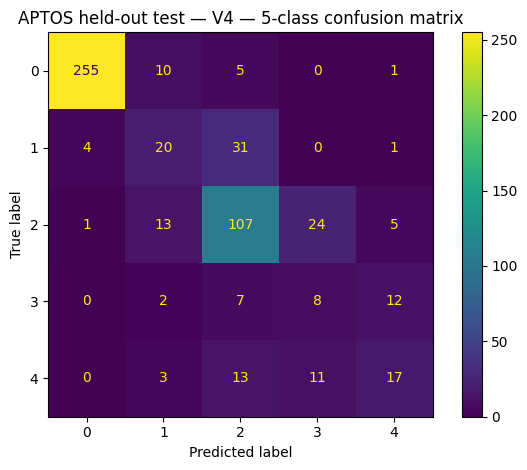

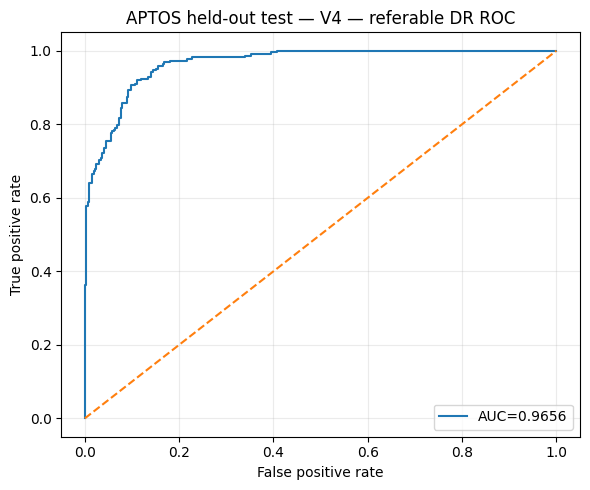

In [21]:

# Cell 18 — Unified calibrated evaluation helper and final held-out APTOS test

def calibrated_predictions(candidate_model, df):
    grade_raw, binary_raw = predict_df(candidate_model, df)

    grade_cal = temperature_scale(grade_raw, GRADE_TEMPERATURE)
    grade_ref = grade_cal[:, 2:].sum(axis=1)

    fused_raw = (
        SCREEN_FUSION_ALPHA * binary_raw
        + (1.0 - SCREEN_FUSION_ALPHA) * grade_ref
    )

    ref_cal = calibrate_screen_probability(fused_raw)

    return grade_cal, ref_cal

def evaluate_classification(candidate_model, df, dataset_name, save_prefix=None):
    grade_probs, ref_probs = calibrated_predictions(candidate_model, df)

    y = df["label"].to_numpy(dtype=int)
    pred_grade = grade_probs.argmax(axis=1)

    y_ref = (y >= 2).astype(int)
    pred_ref = (ref_probs >= REF_THRESHOLD).astype(int)

    acc = accuracy_score(y, pred_grade)
    qwk = cohen_kappa_score(y, pred_grade, weights="quadratic")
    auc = roc_auc_score(y_ref, ref_probs)

    tn, fp, fn, tp = confusion_matrix(
        y_ref,
        pred_ref,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    metrics = {
        "dataset": dataset_name,
        "n": int(len(df)),
        "five_class_accuracy": float(acc),
        "qwk": float(qwk),
        "referable_auc": float(auc),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    print("=" * 78)
    print(dataset_name)
    print("=" * 78)
    print(json.dumps(metrics, indent=2))

    print("\n5-class report:")
    print(
        classification_report(
            y,
            pred_grade,
            labels=[0, 1, 2, 3, 4],
            zero_division=0,
        )
    )

    if save_prefix:
        pred_df = df.copy()
        pred_df["predicted_grade"] = pred_grade
        pred_df["referable_probability"] = ref_probs
        pred_df["referable_true"] = y_ref
        pred_df["referable_prediction"] = pred_ref

        for c in range(5):
            pred_df[f"p_grade_{c}"] = grade_probs[:, c]

        pred_df.to_csv(
            OUTPUT_ROOT / f"{save_prefix}_predictions.csv",
            index=False,
        )

        ConfusionMatrixDisplay.from_predictions(
            y,
            pred_grade,
            labels=[0, 1, 2, 3, 4],
        )
        plt.title(f"{dataset_name} — 5-class confusion matrix")
        plt.tight_layout()
        plt.savefig(
            OUTPUT_ROOT / f"{save_prefix}_5class_confusion.png",
            dpi=170,
            bbox_inches="tight",
        )
        plt.show()

        fpr_, tpr_, _ = roc_curve(y_ref, ref_probs)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr_, tpr_, label=f"AUC={auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate")
        plt.title(f"{dataset_name} — referable DR ROC")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(
            OUTPUT_ROOT / f"{save_prefix}_roc.png",
            dpi=170,
            bbox_inches="tight",
        )
        plt.show()

    return metrics

aptos_test_metrics = evaluate_classification(
    model,
    test_df,
    dataset_name="APTOS held-out test — V4",
    save_prefix="aptos_v4",
)


Messidor CSV member: messidor_data.csv
Columns            : ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable']
Image column       : id_code
DR grade column    : diagnosis
Explicitly ungradable rows: 0
messidor ZIP filename match rate: 1.0000


Cache messidor:   0%|          | 0/1744 [00:00<?, ?it/s]


Messidor final external-test distribution:
label
0    1017
1     270
2     347
3      75
4      35
Name: count, dtype: int64
External images: 1744
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 583ms/step
Messidor-2 untouched external test — V4
{
  "dataset": "Messidor-2 untouched external test \u2014 V4",
  "n": 1744,
  "five_class_accuracy": 0.6244266055045872,
  "qwk": 0.563771965532138,
  "referable_auc": 0.8116920764623172,
  "sensitivity": 0.6849015317286652,
  "specificity": 0.8010878010878011,
  "tn": 1031,
  "fp": 256,
  "fn": 144,
  "tp": 313
}

5-class report:
              precision    recall  f1-score   support

           0       0.71      0.84      0.77      1017
           1       0.22      0.08      0.12       270
           2       0.44      0.47      0.45       347
           3       0.67      0.57      0.62        75
           4       0.55      0.31      0.40        35

    accuracy                           0.62      1744
   macro avg       0.52      0.45      0.47      1744
wei

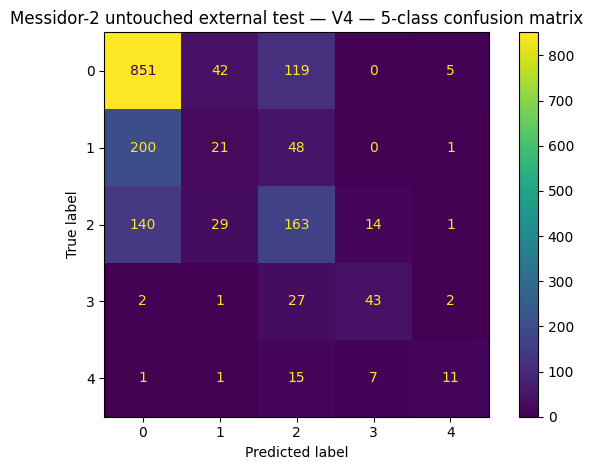

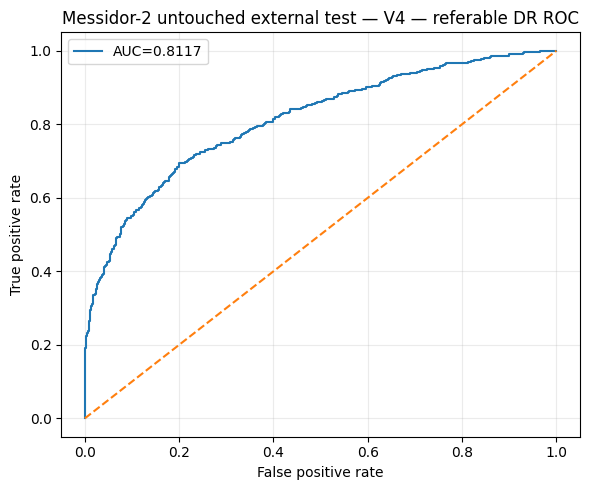

In [22]:

# Cell 19 — Untouched Messidor-2 external test (never used in V4 training)

messidor_raw, messidor_csv_member = read_csv_from_zip(
    MESSIDOR_ZIP,
    preferred_names=["messidor_data.csv"],
)

mess_id_col, mess_grade_col = infer_id_and_grade_columns(messidor_raw)

print("Messidor CSV member:", messidor_csv_member)
print("Columns            :", list(messidor_raw.columns))
print("Image column       :", mess_id_col)
print("DR grade column    :", mess_grade_col)

if mess_id_col is None or mess_grade_col is None:
    raise RuntimeError("Could not identify Messidor-2 image/grade columns.")

messidor = messidor_raw.copy()
messidor["label"] = pd.to_numeric(
    messidor[mess_grade_col],
    errors="coerce",
)

gradable_col = find_col(
    messidor,
    ["adjudicated_gradable", "gradable", "gradability"],
)

if gradable_col is not None:
    g = messidor[gradable_col].astype(str).str.strip().str.lower()
    explicit_bad = g.isin(
        ["0", "false", "f", "no", "n", "ungradable", "not gradable", "not_gradable"]
    )
    print("Explicitly ungradable rows:", int(explicit_bad.sum()))
    messidor = messidor[~explicit_bad].copy()

messidor = messidor.dropna(subset=["label"]).copy()
messidor["label"] = messidor["label"].astype(int)
messidor = messidor[messidor["label"].between(0, 4)].reset_index(drop=True)

MESSIDOR_CACHE = CACHE_ROOT / "messidor"

messidor_cached = cache_manifest_from_zip(
    MESSIDOR_ZIP,
    messidor,
    mess_id_col,
    MESSIDOR_CACHE,
    source_name="messidor",
    require_match_rate=0.90,
)

print("\nMessidor final external-test distribution:")
print(messidor_cached["label"].value_counts().sort_index())
print("External images:", len(messidor_cached))

messidor_metrics = evaluate_classification(
    model,
    messidor_cached,
    dataset_name="Messidor-2 untouched external test — V4",
    save_prefix="messidor_v4",
)


In [23]:

# Cell 20 — Compare V3 baseline and V4 where previous results are available

benchmark_rows = []

def load_json_if_exists(path):
    path = Path(path)

    if path.exists():
        try:
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            return None

    return None

v3_summary = None

for candidate in [
    DRIVE_ROOT / "outputs_v3_fixed" / "run_summary.json",
    DRIVE_ROOT / "outputs_v3" / "run_summary.json",
]:
    v3_summary = load_json_if_exists(candidate)

    if v3_summary is not None:
        break

if v3_summary is not None:
    c = v3_summary.get("classifier", {})

    benchmark_rows.append(
        {
            "model": "V3 APTOS-only",
            "dataset": "APTOS held-out test",
            "n": np.nan,
            "five_class_accuracy": c.get("aptos_test_accuracy"),
            "qwk": c.get("aptos_test_qwk"),
            "referable_auc": c.get("aptos_test_referable_auc"),
            "sensitivity": c.get("aptos_test_sensitivity"),
            "specificity": c.get("aptos_test_specificity"),
        }
    )

old_messidor_metrics = None

for root in [
    DRIVE_ROOT / "outputs_v3_fixed",
    DRIVE_ROOT / "outputs_v3",
]:
    if not root.exists():
        continue

    matches = list(root.rglob("messidor2_external_metrics.json"))

    if matches:
        old_messidor_metrics = load_json_if_exists(matches[0])

        if old_messidor_metrics:
            break

if old_messidor_metrics:
    benchmark_rows.append(
        {
            "model": "V3 APTOS-only",
            "dataset": "Messidor-2 external",
            "n": old_messidor_metrics.get("n"),
            "five_class_accuracy": old_messidor_metrics.get("five_class_accuracy"),
            "qwk": old_messidor_metrics.get("quadratic_weighted_kappa"),
            "referable_auc": old_messidor_metrics.get("referable_auc"),
            "sensitivity": old_messidor_metrics.get("sensitivity"),
            "specificity": old_messidor_metrics.get("specificity"),
        }
    )

benchmark_rows.extend(
    [
        {
            "model": "V4 multi-domain",
            "dataset": "APTOS held-out test",
            **{
                k: aptos_test_metrics.get(k)
                for k in [
                    "n",
                    "five_class_accuracy",
                    "qwk",
                    "referable_auc",
                    "sensitivity",
                    "specificity",
                ]
            },
        },
        {
            "model": "V4 multi-domain",
            "dataset": "Messidor-2 untouched external",
            **{
                k: messidor_metrics.get(k)
                for k in [
                    "n",
                    "five_class_accuracy",
                    "qwk",
                    "referable_auc",
                    "sensitivity",
                    "specificity",
                ]
            },
        },
    ]
)

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_path = OUTPUT_ROOT / "v3_vs_v4_benchmark.csv"
benchmark_df.to_csv(benchmark_path, index=False)

display(benchmark_df)
print("Saved:", benchmark_path)


,model,dataset,n,five_class_accuracy,qwk,referable_auc,sensitivity,specificity
0,V3 APTOS-only,APTOS held-out test,NaN,0.772727,0.820173,0.969885,0.905830,0.889908
1,V3 APTOS-only,Messidor-2 external,1744.0,0.592890,0.205077,0.754915,0.201313,0.982129
2,V4 multi-domain,APTOS held-out test,550.0,0.740000,0.853365,0.965593,0.959641,0.840979
3,V4 multi-domain,Messidor-2 untouched external,1744.0,0.624427,0.563772,0.811692,0.684902,0.801088


Saved: /content/drive/MyDrive/sih/outputs_v4_multidomain/v3_vs_v4_benchmark.csv


In [24]:

# Cell 21 — Build referable-DR Grad-CAM and restore the existing IDRiD U-Net

def build_referable_gradcam_model(classifier):
    backbone = classifier.get_layer("efficientnetb0")
    last_conv = backbone.get_layer("top_conv")

    feature_extractor = keras.Model(
        backbone.input,
        [last_conv.output, backbone.output],
        name="v4_gradcam_feature_extractor",
    )

    grad_input = keras.Input(shape=(*CLS_SIZE, 3))

    conv_features, backbone_features = feature_extractor(
        grad_input,
        training=False,
    )

    x = classifier.get_layer("gap")(backbone_features)
    x = classifier.get_layer("referable_dropout")(x, training=False)
    ref_logit = classifier.get_layer("referable_logit")(x)

    return keras.Model(
        grad_input,
        [conv_features, ref_logit],
        name="v4_referable_gradcam",
    )

grad_model = build_referable_gradcam_model(model)

def make_referable_gradcam(classifier_image):
    x = tf.convert_to_tensor(
        classifier_image[None, ...],
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        conv_features, ref_logit = grad_model(x, training=False)
        score = ref_logit[:, 0]

    grads = tape.gradient(score, conv_features)
    weights = tf.reduce_mean(grads, axis=(1, 2))

    cam = tf.reduce_sum(
        conv_features * weights[:, None, None, :],
        axis=-1,
    )[0]

    cam = tf.maximum(cam, 0.0)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    cam = cv2.resize(
        cam.numpy(),
        (CLS_SIZE[1], CLS_SIZE[0]),
        interpolation=cv2.INTER_LINEAR,
    )

    return cam

SEG_SIZE = (384, 384)

def decoder_block(x, skip, filters, name):
    x = layers.Conv2DTranspose(
        filters,
        3,
        strides=2,
        padding="same",
        use_bias=False,
        name=name + "_up",
    )(x)

    x = layers.Concatenate(name=name + "_concat")([x, skip])

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        name=name + "_conv1",
    )(x)
    x = layers.BatchNormalization(name=name + "_bn1")(x)
    x = layers.Activation("relu", name=name + "_relu1")(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        name=name + "_conv2",
    )(x)
    x = layers.BatchNormalization(name=name + "_bn2")(x)
    x = layers.Activation("relu", name=name + "_relu2")(x)

    return x

def build_existing_lesion_unet():
    base = keras.applications.MobileNetV2(
        input_shape=(*SEG_SIZE, 3),
        include_top=False,
        weights=None,
    )

    skip_names = [
        "block_1_expand_relu",
        "block_3_expand_relu",
        "block_6_expand_relu",
        "block_13_expand_relu",
        "block_16_project",
    ]

    down_stack = keras.Model(
        inputs=base.input,
        outputs=[base.get_layer(name).output for name in skip_names],
        name="mobilenetv2_encoder",
    )
    down_stack.trainable = False

    inputs = keras.Input(shape=(*SEG_SIZE, 3), name="seg_fundus")

    x = layers.Rescaling(
        scale=1.0 / 127.5,
        offset=-1.0,
        name="mobilenet_preprocess",
    )(inputs)

    s1, s2, s3, s4, bottleneck = down_stack(x, training=False)

    x = decoder_block(bottleneck, s4, 256, "dec4")
    x = decoder_block(x, s3, 128, "dec3")
    x = decoder_block(x, s2, 64, "dec2")
    x = decoder_block(x, s1, 32, "dec1")

    x = layers.Conv2DTranspose(
        24,
        3,
        strides=2,
        padding="same",
        activation="relu",
        name="final_up",
    )(x)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid",
        name="lesion_probability",
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="IDRiD_Lesion_UNet",
    )

def find_seg_weights():
    for root in [
        DRIVE_ROOT / "outputs_v3_fixed",
        DRIVE_ROOT / "outputs_v3",
    ]:
        if not root.exists():
            continue

        matches = list(root.rglob("idrid_lesion_unet_final.weights.h5"))

        if matches:
            return matches[0]

    return None

SEG_WEIGHTS = find_seg_weights()
SEG_AVAILABLE = SEG_WEIGHTS is not None
SEG_THRESHOLD = 0.85

if v3_summary is not None:
    try:
        SEG_THRESHOLD = float(
            v3_summary["segmentation"]["validation_threshold"]
        )
    except Exception:
        pass

if SEG_AVAILABLE:
    seg_model = build_existing_lesion_unet()
    seg_model.load_weights(SEG_WEIGHTS)

    print("Loaded existing U-Net:", SEG_WEIGHTS)
    print("Segmentation threshold:", SEG_THRESHOLD)
else:
    seg_model = None

    print("WARNING: existing segmentation weights were not found.")
    print("Classification V4 is complete; report generation will omit U-Net masks.")


Loaded existing U-Net: /content/drive/MyDrive/sih/outputs_v3/idrid_lesion_unet_final.weights.h5
Segmentation threshold: 0.8500000000000002


In [26]:
# Cell 22 — Explainable single-image inference and PDF report generator
# FIXED VERSION: handles mixed-precision Grad-CAM safely

from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4

REPORT_DIR = OUTPUT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

GRADE_NAMES = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR",
}


# ============================================================
# FIXED GRAD-CAM
# ============================================================

def make_referable_gradcam(classifier_image):
    """
    Generate Grad-CAM for the V4 referable-DR head.

    Important fix:
    Mixed precision may produce float16 tensors.
    OpenCV resize can fail on float16, so the heatmap is
    explicitly converted to float32 before cv2.resize().
    """

    x = tf.convert_to_tensor(
        classifier_image[None, ...],
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        conv_features, ref_logit = grad_model(
            x,
            training=False,
        )

        # Use referable pre-sigmoid score
        score = ref_logit[:, 0]

    grads = tape.gradient(
        score,
        conv_features,
    )

    if grads is None:
        raise RuntimeError(
            "Grad-CAM gradients are None. "
            "Check the V4 referable Grad-CAM model."
        )

    # Force float32 because mixed precision may produce float16
    conv_features = tf.cast(
        conv_features,
        tf.float32,
    )

    grads = tf.cast(
        grads,
        tf.float32,
    )

    # Global-average-pool gradients
    weights = tf.reduce_mean(
        grads,
        axis=(1, 2),
    )

    # Weighted sum of activation channels
    cam = tf.reduce_sum(
        conv_features
        * weights[:, None, None, :],
        axis=-1,
    )[0]

    # ReLU
    cam = tf.nn.relu(cam)

    cam_max = tf.reduce_max(cam)

    if float(cam_max.numpy()) > 0:
        cam = cam / cam_max
    else:
        cam = tf.zeros_like(cam)

    # -----------------------------------------
    # IMPORTANT FIX FOR THE OPENCV ERROR
    # -----------------------------------------
    cam = tf.cast(
        cam,
        tf.float32,
    ).numpy()

    cam = np.asarray(
        cam,
        dtype=np.float32,
    )

    cam = np.ascontiguousarray(cam)

    # Protect against NaN / inf
    cam = np.nan_to_num(
        cam,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    )

    if cam.ndim != 2:
        cam = np.squeeze(cam)

    if cam.ndim != 2:
        raise RuntimeError(
            f"Unexpected Grad-CAM shape: {cam.shape}"
        )

    cam = cv2.resize(
        cam,
        (
            int(CLS_SIZE[1]),
            int(CLS_SIZE[0]),
        ),
        interpolation=cv2.INTER_LINEAR,
    )

    cam = np.clip(
        cam,
        0.0,
        1.0,
    ).astype(np.float32)

    return cam


# ============================================================
# IMAGE PREPARATION
# ============================================================

def prepare_classifier_image_from_file(filepath):
    bgr = cv2.imread(str(filepath))

    if bgr is None:
        raise ValueError(
            f"Unreadable image: {filepath}"
        )

    bgr = preprocess_bgr_to_classifier(bgr)

    if bgr is None or bgr.size == 0:
        raise ValueError(
            f"Classifier preprocessing failed: {filepath}"
        )

    rgb = cv2.cvtColor(
        bgr,
        cv2.COLOR_BGR2RGB,
    )

    return rgb.astype(np.float32)


def prepare_segmentation_image_from_file(filepath):
    bgr = cv2.imread(str(filepath))

    if bgr is None:
        raise ValueError(
            f"Unreadable image: {filepath}"
        )

    crop = black_border_crop_bgr(bgr)

    if crop is None or crop.size == 0:
        raise ValueError(
            f"Segmentation preprocessing failed: {filepath}"
        )

    rgb = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB,
    )

    rgb = cv2.resize(
        rgb,
        (
            SEG_SIZE[1],
            SEG_SIZE[0],
        ),
        interpolation=cv2.INTER_AREA,
    )

    return rgb.astype(np.float32)


# ============================================================
# COMPLETE V4 INFERENCE
# ============================================================

def infer_v4_image(filepath):

    # --------------------------------------------------------
    # CLASSIFIER
    # --------------------------------------------------------

    cls_img = prepare_classifier_image_from_file(
        filepath
    )

    pred = model.predict(
        cls_img[None, ...],
        verbose=0,
    )

    grade_raw, binary_raw = unpack_prediction(pred)

    # Temperature-calibrated grade probabilities
    grade_cal = temperature_scale(
        grade_raw,
        GRADE_TEMPERATURE,
    )[0]

    # Grade-derived referable probability
    p_grade_ref = float(
        grade_cal[2:].sum()
    )

    # Dedicated binary screening head
    p_binary = float(
        binary_raw[0]
    )

    # Validation-selected fusion
    fused_raw = (
        SCREEN_FUSION_ALPHA * p_binary
        + (1.0 - SCREEN_FUSION_ALPHA)
        * p_grade_ref
    )

    # Platt calibrated screening probability
    p_ref = float(
        calibrate_screen_probability(
            [fused_raw]
        )[0]
    )

    predicted_grade = int(
        np.argmax(grade_cal)
    )

    grade_confidence = float(
        grade_cal[predicted_grade]
    )

    referral = bool(
        p_ref >= REF_THRESHOLD
    )

    # --------------------------------------------------------
    # GRAD-CAM
    # --------------------------------------------------------

    cam = make_referable_gradcam(
        cls_img
    )

    # --------------------------------------------------------
    # U-NET LESION LOCALIZATION
    # --------------------------------------------------------

    lesion_prob = None
    lesion_binary = None
    seg_img = None

    if SEG_AVAILABLE:

        seg_img = prepare_segmentation_image_from_file(
            filepath
        )

        lesion_pred = seg_model.predict(
            seg_img[None, ...],
            verbose=0,
        )

        lesion_prob = np.asarray(
            lesion_pred[0, ..., 0],
            dtype=np.float32,
        )

        lesion_binary = (
            lesion_prob >= SEG_THRESHOLD
        )

    return {
        "classifier_image": cls_img,

        "grade_probabilities": grade_cal,

        "predicted_grade": predicted_grade,

        "grade_label":
            GRADE_NAMES[predicted_grade],

        "calibrated_confidence":
            grade_confidence,

        "referable_probability":
            p_ref,

        "referral_decision":
            "REFER"
            if referral
            else "NON-REFER",

        "gradcam":
            cam,

        "segmentation_image":
            seg_img,

        "lesion_probability":
            lesion_prob,

        "lesion_mask":
            lesion_binary,
    }


# ============================================================
# REPORT GENERATOR
# ============================================================

def save_v4_review_report(
    filepath,
    out_name="v4_review",
):

    result = infer_v4_image(
        filepath
    )

    # --------------------------------------------------------
    # Original classifier input
    # --------------------------------------------------------

    cls_rgb = np.clip(
        result["classifier_image"]
        / 255.0,
        0.0,
        1.0,
    ).astype(np.float32)

    # --------------------------------------------------------
    # Grad-CAM visualization
    # --------------------------------------------------------

    gradcam = np.asarray(
        result["gradcam"],
        dtype=np.float32,
    )

    gradcam = np.clip(
        gradcam,
        0.0,
        1.0,
    )

    cam_rgb = plt.get_cmap(
        "jet"
    )(gradcam)[..., :3]

    cam_rgb = np.asarray(
        cam_rgb,
        dtype=np.float32,
    )

    cam_overlay = np.clip(
        0.60 * cls_rgb
        + 0.40 * cam_rgb,
        0.0,
        1.0,
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    panels = (
        3
        if SEG_AVAILABLE
        else 2
    )

    fig, ax = plt.subplots(
        1,
        panels,
        figsize=(5 * panels, 5),
    )

    ax = np.atleast_1d(ax)

    # Original image
    ax[0].imshow(cls_rgb)

    ax[0].set_title(
        "Classifier Input"
    )

    ax[0].axis("off")

    # Grad-CAM
    ax[1].imshow(
        cam_overlay
    )

    ax[1].set_title(
        "Classifier Attention — Grad-CAM"
    )

    ax[1].axis("off")

    # --------------------------------------------------------
    # U-Net visualization
    # --------------------------------------------------------

    if SEG_AVAILABLE:

        seg_rgb = np.clip(
            result["segmentation_image"]
            / 255.0,
            0.0,
            1.0,
        ).astype(np.float32)

        lesion_mask = np.asarray(
            result["lesion_mask"],
            dtype=np.float32,
        )

        lesion_color = np.zeros_like(
            seg_rgb,
            dtype=np.float32,
        )

        # Red overlay for lesion mask
        lesion_color[..., 0] = (
            lesion_mask
        )

        seg_overlay = np.clip(
            0.75 * seg_rgb
            + 0.50 * lesion_color,
            0.0,
            1.0,
        )

        ax[2].imshow(
            seg_overlay
        )

        ax[2].set_title(
            "Lesion Localization — U-Net"
        )

        ax[2].axis("off")

    # --------------------------------------------------------
    # Figure title
    # --------------------------------------------------------

    plt.suptitle(
        (
            f"Grade "
            f"{result['predicted_grade']} "
            f"({result['grade_label']})"
            f" | Referable P="
            f"{result['referable_probability']:.3f}"
            f" | "
            f"{result['referral_decision']}"
        ),
        fontsize=12,
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save visualization
    # --------------------------------------------------------

    png_path = (
        REPORT_DIR
        / f"{out_name}.png"
    )

    plt.savefig(
        png_path,
        dpi=170,
        bbox_inches="tight",
    )

    plt.close(fig)

    # --------------------------------------------------------
    # PDF
    # --------------------------------------------------------

    pdf_path = (
        REPORT_DIR
        / f"{out_name}.pdf"
    )

    c = canvas.Canvas(
        str(pdf_path),
        pagesize=A4,
    )

    c.drawString(
        40,
        810,
        "Explainable Diabetic Retinopathy Screening — V4",
    )

    c.drawString(
        40,
        790,
        (
            f"Predicted grade: "
            f"{result['predicted_grade']} "
            f"({result['grade_label']})"
        ),
    )

    c.drawString(
        40,
        770,
        (
            "Calibrated grade confidence: "
            f"{result['calibrated_confidence']:.3f}"
        ),
    )

    c.drawString(
        40,
        750,
        (
            "Referable-DR probability: "
            f"{result['referable_probability']:.3f}"
        ),
    )

    c.drawString(
        40,
        730,
        (
            "Referral decision: "
            f"{result['referral_decision']}"
        ),
    )

    c.drawString(
        40,
        710,
        (
            "Referral threshold: "
            f"{REF_THRESHOLD:.4f}"
        ),
    )

    c.drawString(
        40,
        690,
        (
            "Grad-CAM shows classifier attention; "
            "it is not precise lesion localization."
        ),
    )

    if SEG_AVAILABLE:

        c.drawString(
            40,
            670,
            (
                "U-Net lesion threshold: "
                f"{SEG_THRESHOLD:.2f}"
            ),
        )

    c.drawImage(
        str(png_path),
        35,
        225,
        width=525,
        height=410,
        preserveAspectRatio=True,
        anchor="c",
    )

    c.drawString(
        40,
        190,
        (
            "Screening decision-support prototype only; "
            "not a clinical diagnosis."
        ),
    )

    c.save()

    return {
        "png":
            str(png_path),

        "pdf":
            str(pdf_path),

        "predicted_grade":
            result["predicted_grade"],

        "grade_label":
            result["grade_label"],

        "grade_probabilities":
            [
                float(x)
                for x
                in result["grade_probabilities"]
            ],

        "calibrated_confidence":
            result["calibrated_confidence"],

        "referable_probability":
            result["referable_probability"],

        "referral_decision":
            result["referral_decision"],
    }


# ============================================================
# TEST ON ONE UNTOUCHED APTOS TEST IMAGE
# ============================================================

print("=" * 78)
print("GENERATING SAMPLE V4 EXPLAINABILITY REPORT")
print("=" * 78)

sample_filepath = test_df.iloc[0]["filepath"]

print(
    "Sample image:",
    sample_filepath,
)

sample_report = save_v4_review_report(
    sample_filepath,
    out_name="sample_v4_aptos_review",
)

print("\nReport generated successfully:\n")

print(
    json.dumps(
        sample_report,
        indent=2,
    )
)

GENERATING SAMPLE V4 EXPLAINABILITY REPORT
Sample image: /content/dr_v4_work/cache/aptos/aptos_89ee1fa16f90.jpg

Report generated successfully:

{
  "png": "/content/drive/MyDrive/sih/outputs_v4_multidomain/reports/sample_v4_aptos_review.png",
  "pdf": "/content/drive/MyDrive/sih/outputs_v4_multidomain/reports/sample_v4_aptos_review.pdf",
  "predicted_grade": 2,
  "grade_label": "Moderate DR",
  "grade_probabilities": [
    0.0004295968646036329,
    0.027468568718276527,
    0.703657738160755,
    0.2180376757026633,
    0.05040642055370153
  ],
  "calibrated_confidence": 0.703657738160755,
  "referable_probability": 0.984445425229335,
  "referral_decision": "REFER"
}


In [ ]:

# Cell 23 — Save calibration, deployment configuration and final run summary

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

CALIBRATION = {
    "grade_temperature": GRADE_TEMPERATURE,
    "screen_fusion_alpha_binary_head": SCREEN_FUSION_ALPHA,
    "screen_fusion_alpha_grade_sum": 1.0 - SCREEN_FUSION_ALPHA,
    "platt_a": PLATT_A,
    "platt_b": PLATT_B,
    "referral_threshold": REF_THRESHOLD,
    "threshold_rule": threshold_rule,
}

DEPLOYMENT_CONFIG = {
    "model_version": "V4 multi-domain",
    "classifier_path": str(FINAL_CLASSIFIER),
    "classifier_input_size": list(CLS_SIZE),
    "classifier_input_range": "float32 0-255",
    "preprocessing": [
        "decode RGB fundus image",
        "crop excess black border using pixel threshold 10",
        "resize directly to 300x300",
        "keep pixels in 0-255 range",
        "do not divide by 255 because Keras EfficientNetB0 contains internal rescaling",
    ],
    "grade_classes": {
        "0": "No DR",
        "1": "Mild DR",
        "2": "Moderate DR",
        "3": "Severe DR",
        "4": "Proliferative DR",
    },
    "screening": {
        "referable_definition": "grade >= 2",
        **CALIBRATION,
    },
    "segmentation": {
        "weights_path": str(SEG_WEIGHTS) if SEG_WEIGHTS else None,
        "input_size": list(SEG_SIZE),
        "threshold": SEG_THRESHOLD if SEG_AVAILABLE else None,
        "target": "binary union of microaneurysms, hemorrhages, hard exudates, soft exudates",
    },
    "responsible_use": "Screening decision-support prototype only; not a clinical diagnosis.",
}

summary = {
    "project": "Explainable DR Screening V4 Multi-Domain",
    "seed": SEED,
    "config": CONFIG,
    "training_sources": {
        "aptos_train": int((train_df["source"] == "aptos").sum()),
        "eyepacs_train": int((train_df["source"] == "eyepacs").sum()),
        "ddr_train": int((train_df["source"] == "ddr").sum()),
    },
    "validation_sources": {
        "aptos_val": int((val_df["source"] == "aptos").sum()),
        "eyepacs_val": int((val_df["source"] == "eyepacs").sum()),
        "ddr_val": int((val_df["source"] == "ddr").sum()),
    },
    "selected_classifier_stage": selected_stage,
    "selected_validation_metrics_raw": selected_val_metrics,
    "calibration": CALIBRATION,
    "aptos_final_test": aptos_test_metrics,
    "messidor_external_test": messidor_metrics,
    "segmentation_reused": bool(SEG_AVAILABLE),
    "segmentation_threshold": safe_float(SEG_THRESHOLD) if SEG_AVAILABLE else None,
    "paths": {
        "classifier": str(FINAL_CLASSIFIER),
        "output_root": str(OUTPUT_ROOT),
        "train_manifest": str(MANIFEST_DIR / "train_manifest.csv"),
        "validation_manifest": str(MANIFEST_DIR / "validation_manifest.csv"),
        "aptos_test_manifest": str(MANIFEST_DIR / "aptos_final_test_manifest.csv"),
    },
    "methodology": {
        "messidor_used_in_training": False,
        "messidor_used_for_calibration": False,
        "messidor_used_for_threshold_selection": False,
        "eyepacs_source": "ctmedtech/EYEPACS downloaded directly from Hugging Face",
        "screening_decision": (
            "calibrated validation-selected fusion of binary screening head "
            "and P(grade 2-4)"
        ),
    },
}

with open(OUTPUT_ROOT / "calibration_v4.json", "w", encoding="utf-8") as f:
    json.dump(CALIBRATION, f, indent=2)

with open(OUTPUT_ROOT / "deployment_config_v4.json", "w", encoding="utf-8") as f:
    json.dump(DEPLOYMENT_CONFIG, f, indent=2)

with open(OUTPUT_ROOT / "run_summary_v4.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 78)
print("V4 RUN COMPLETE")
print("=" * 78)
print("Classifier:", FINAL_CLASSIFIER)
print("Selected stage:", selected_stage)

print("\nAPTOS held-out:")
print(json.dumps(aptos_test_metrics, indent=2))

print("\nMessidor untouched external:")
print(json.dumps(messidor_metrics, indent=2))

print("\nCalibration:")
print(json.dumps(CALIBRATION, indent=2))


In [ ]:

# Cell 24 — Output audit

print("Files saved under:", OUTPUT_ROOT)

for p in sorted(OUTPUT_ROOT.rglob("*")):
    if p.is_file():
        try:
            size_mb = p.stat().st_size / (1024 ** 2)
            print(f" - {p.relative_to(OUTPUT_ROOT)}  ({size_mb:.2f} MB)")
        except Exception:
            print(" -", p.relative_to(OUTPUT_ROOT))

required_outputs = [
    OUTPUT_ROOT / "dr_multidomain_efficientnetb0_v4.keras",
    OUTPUT_ROOT / "run_summary_v4.json",
    OUTPUT_ROOT / "deployment_config_v4.json",
    OUTPUT_ROOT / "calibration_v4.json",
    OUTPUT_ROOT / "v3_vs_v4_benchmark.csv",
    OUTPUT_ROOT / "aptos_v4_predictions.csv",
    OUTPUT_ROOT / "messidor_v4_predictions.csv",
]

missing = [str(p) for p in required_outputs if not p.exists()]

if missing:
    print("\nWARNING — expected files missing:")

    for p in missing:
        print(" -", p)
else:
    print("\nAll required V4 output artifacts are present.")



## Final interpretation

Use the **Messidor-2 V4 result** as the main cross-dataset generalization test.

A scientifically safe project narrative is:

> The initial APTOS-only classifier showed strong internal performance but substantial domain shift on Messidor-2. V4 therefore used multi-domain training on APTOS, EyePACS and DDR, while preserving Messidor-2 as an untouched external test set. Calibration, screening-head fusion and referral-threshold selection were performed only on validation data from the training domains.

Do **not** claim that:

- Messidor-2 was used to train V4;
- Messidor-2 was used to tune the referral threshold;
- U-Net was retrained in this notebook;
- Grad-CAM precisely localizes lesions;
- the prototype is clinically validated.

The existing IDRiD U-Net remains the primary lesion-localization explanation. Grad-CAM remains auxiliary classifier-attention evidence.
